In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.tree import (
    DecisionTreeClassifier,
    plot_tree,
    export_text
)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

import warnings
warnings.filterwarnings('ignore')

In [1]:
from google.colab import files
uploaded = files.upload()

Saving car evaluation_with.csv.xls to car evaluation_with.csv.xls


In [5]:
import pandas as pd
df = pd.read_csv('/content/car evaluation_with.csv.xls')
df

,vhigh,vhigh.1,2,2.1,small,med,unacc
0,vhigh,vhigh,2,2,small,high,unacc
1,vhigh,vhigh,2,2,med,low,unacc
2,vhigh,vhigh,2,2,med,med,unacc
3,vhigh,vhigh,2,2,med,high,unacc
4,vhigh,vhigh,2,2,big,low,unacc
...,...,...,...,...,...,...,...
1721,low,low,5,5,med,med,good
1722,low,low,5,5,med,high,vgood
1723,low,low,5,5,big,low,unacc
1724,low,low,5,5,big,med,good


In [6]:
df.describe()

,2,2.1
count,1726.000000,1726.000000
mean,3.501738,3.668598
std,1.117838,1.247011
min,2.000000,2.000000
25%,3.000000,2.000000
50%,4.000000,4.000000
75%,4.750000,5.000000
max,5.000000,5.000000


In [7]:
df.head()

,vhigh,vhigh.1,2,2.1,small,med,unacc
0,vhigh,vhigh,2,2,small,high,unacc
1,vhigh,vhigh,2,2,med,low,unacc
2,vhigh,vhigh,2,2,med,med,unacc
3,vhigh,vhigh,2,2,med,high,unacc
4,vhigh,vhigh,2,2,big,low,unacc


In [14]:
df.columns

Index(['vhigh', 'vhigh.1', '2', '2.1', 'small', 'med', 'unacc'], dtype='object')

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1726 entries, 0 to 1725
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   vhigh    1726 non-null   object
 1   vhigh.1  1726 non-null   object
 2   2        1726 non-null   int64 
 3   2.1      1726 non-null   int64 
 4   small    1726 non-null   object
 5   med      1726 non-null   object
 6   unacc    1726 non-null   object
dtypes: int64(2), object(5)
memory usage: 94.5+ KB


In [11]:
df.shape

(1726, 7)

In [12]:
df.isnull().sum()

,0
vhigh,0
vhigh.1,0
2,0
2.1,0
small,0
med,0
unacc,0


In [15]:
target = "unacc"


print("\nClass Distribution")

print(
    df[target].value_counts()
)


Class Distribution
unacc
unacc    1208
acc       384
good       69
vgood      65
Name: count, dtype: int64


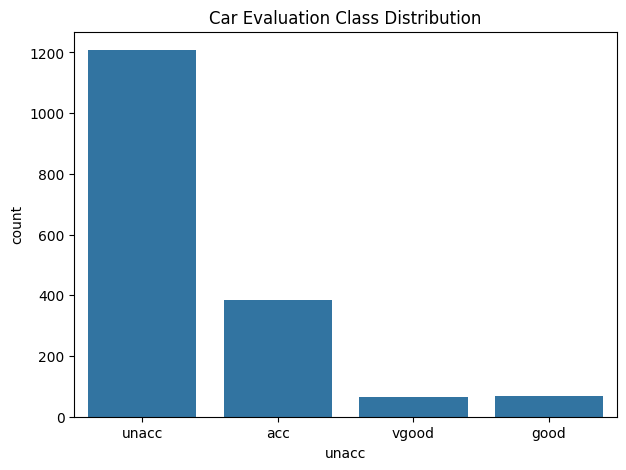

In [16]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x=target
)

plt.title(
    "Car Evaluation Class Distribution"
)

plt.show()

In [18]:
df_encoded = df.copy()


label_encoders={}


for col in df_encoded.columns:

    le = LabelEncoder()

    df_encoded[col] = le.fit_transform(
        df_encoded[col]
    )

    label_encoders[col]=le



print("\nEncoded Data")

display(
    df_encoded.head()
)




Encoded Data


,vhigh,vhigh.1,2,2.1,small,med,unacc
0,3,3,0,0,2,0,2
1,3,3,0,0,1,1,2
2,3,3,0,0,1,2,2
3,3,3,0,0,1,0,2
4,3,3,0,0,0,1,2


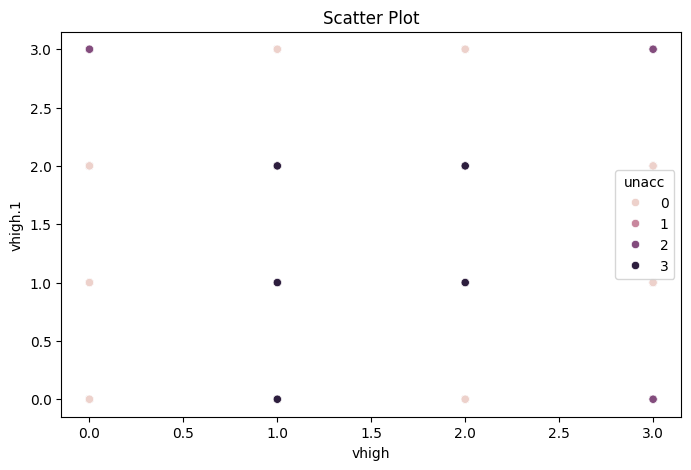

In [20]:
features=list(
    df_encoded.columns
)


plt.figure(figsize=(8,5))


sns.scatterplot(
    data=df_encoded,
    x=features[0],
    y=features[1],
    hue=target
)


plt.title(
    "Scatter Plot"
)


plt.show()

In [21]:

X=df_encoded.drop(
    target,
    axis=1
)


y=df_encoded[target]

In [22]:
X_train,X_test,y_train,y_test=train_test_split(

    X,
    y,

    test_size=0.2,

    random_state=42,

    stratify=y
)

In [24]:

X_train.shape,
X_test.shape


(346, 6)

In [25]:
cart = DecisionTreeClassifier(
    criterion="gini",
    random_state=42
)


In [26]:
cart.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(random_state=42)

In [27]:
cart_pred=cart.predict(
    X_test
)

In [28]:
cart_accuracy=accuracy_score(
    y_test,
    cart_pred
)

In [29]:
"CART Accuracy:",
cart_accuracy

0.9855491329479769

In [30]:

id3 = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)


In [31]:
id3.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [32]:

id3_pred=id3.predict(
    X_test
)


id3_accuracy=accuracy_score(
    y_test,
    id3_pred
)

In [33]:
"ID3 Accuracy:",
id3_accuracy

0.9855491329479769

In [34]:
c45 = DecisionTreeClassifier(
    criterion="entropy",
    random_state=42
)

In [35]:

c45.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [36]:

c45_pred=c45.predict(
    X_test
)

In [37]:

c45_accuracy=accuracy_score(
    y_test,
    c45_pred
)

In [38]:
"C4.5 Accuracy:",
c45_accuracy

0.9855491329479769

In [39]:
parameters={


"criterion":
[
"gini",
"entropy"
],


"max_depth":
[
None,
5,
10,
15,
20
],


"min_samples_split":
[
2,
5,
10
],


"min_samples_leaf":
[
1,
2,
4
]


}



grid=GridSearchCV(

DecisionTreeClassifier(
random_state=42
),

parameters,

cv=5,

scoring="accuracy",

n_jobs=-1

)



grid.fit(
X_train,
y_train
)



best_model=grid.best_estimator_



print(
"\nBest Parameters:"
)

print(
grid.best_params_
)




Best Parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}


In [40]:
best_prediction=best_model.predict(
    X_test
)

In [41]:

best_accuracy=accuracy_score(
    y_test,
    best_prediction
)

In [43]:
print(f"Best Tuned Accuracy: {best_accuracy}")

Best Tuned Accuracy: 0.9855491329479769


,Model,Accuracy
0,CART,0.985549
1,ID3,0.985549
2,C4.5,0.985549
3,Tuned Decision Tree,0.985549


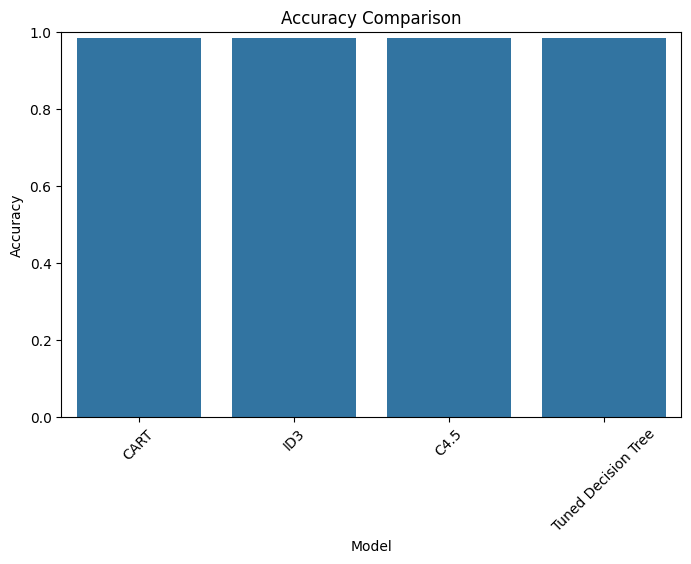

In [44]:
results=pd.DataFrame({

"Model":[

"CART",

"ID3",

"C4.5",

"Tuned Decision Tree"

],


"Accuracy":[

cart_accuracy,

id3_accuracy,

c45_accuracy,

best_accuracy

]

})


display(results)



plt.figure(figsize=(8,5))


sns.barplot(

data=results,

x="Model",

y="Accuracy"

)


plt.ylim(0,1)


plt.title(
"Accuracy Comparison"
)


plt.xticks(rotation=45)


plt.show()




In [46]:
print(
classification_report(
    y_test,
    best_prediction
)
)

              precision    recall  f1-score   support

           0       0.97      0.97      0.97        77
           1       0.82      1.00      0.90        14
           2       1.00      1.00      1.00       242
           3       1.00      0.77      0.87        13

    accuracy                           0.99       346
   macro avg       0.95      0.94      0.94       346
weighted avg       0.99      0.99      0.99       346



,Feature,Importance
5,med,0.247459
1,vhigh.1,0.215222
3,2.1,0.212928
0,vhigh,0.165209
4,small,0.094901
2,2,0.064281


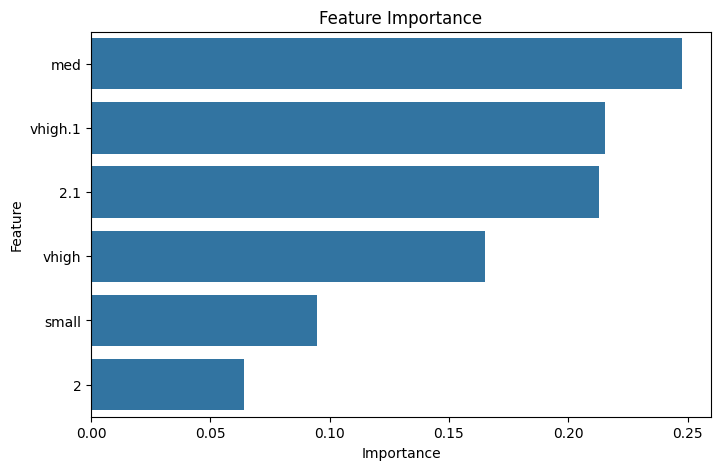

In [47]:
importance=pd.DataFrame({

"Feature":

X.columns,


"Importance":

best_model.feature_importances_

})


importance=importance.sort_values(

by="Importance",

ascending=False

)



display(
importance
)



plt.figure(figsize=(8,5))


sns.barplot(

data=importance,

x="Importance",

y="Feature"

)


plt.title(
"Feature Importance"
)


plt.show()

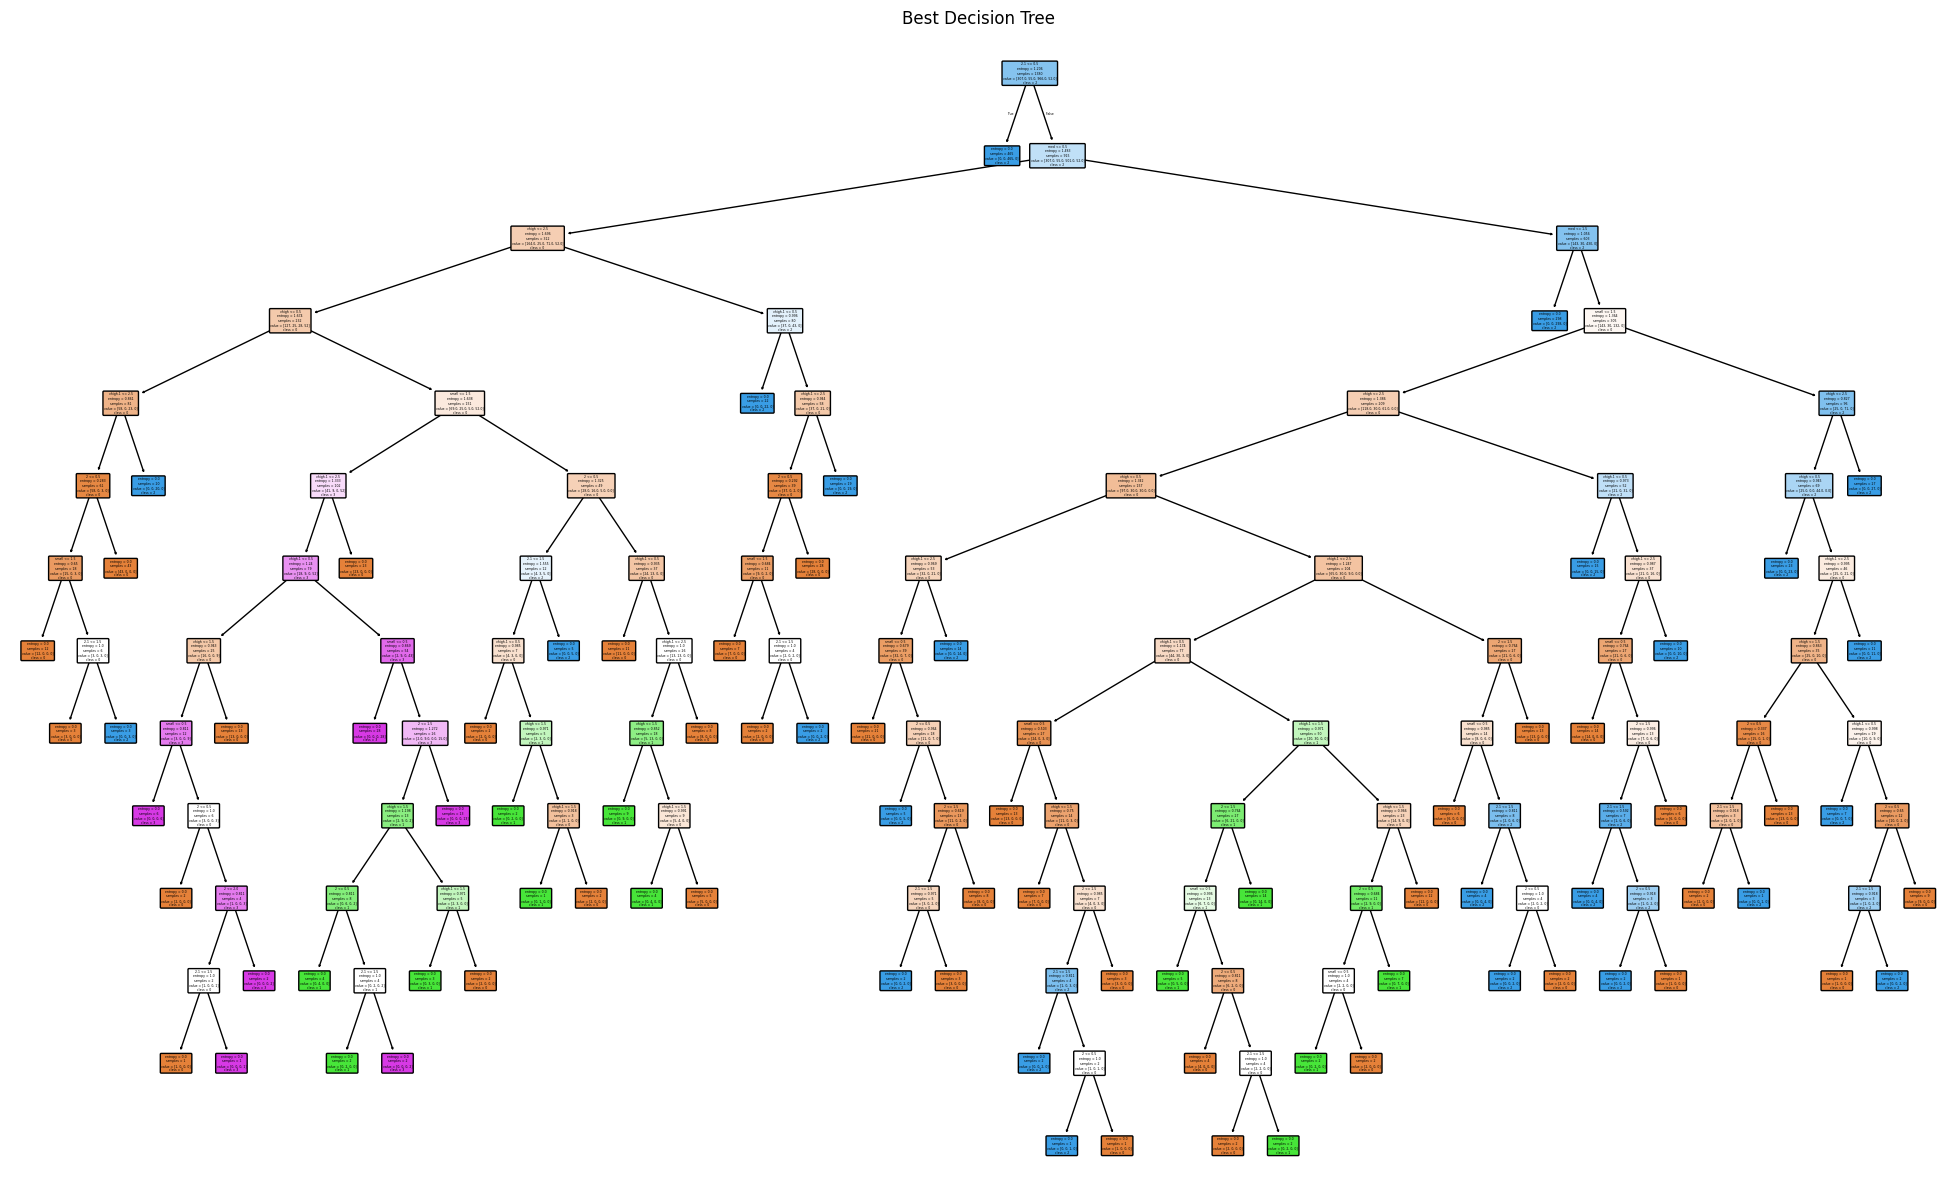

In [48]:
plt.figure(figsize=(25,15))


plot_tree(

best_model,

feature_names=X.columns,

class_names=[

str(i)

for i in sorted(y.unique())

],

filled=True,

rounded=True

)


plt.title(
"Best Decision Tree"
)


plt.show()


In [52]:
print("=============================")

print(
"BEST MODEL:"
)

print(
best_model
)


print(
"FINAL ACCURACY:"
)

print(
best_accuracy
)

print("=============================")

BEST MODEL:
DecisionTreeClassifier(criterion='entropy', random_state=42)
FINAL ACCURACY:
0.9855491329479769
